## Imports

In [34]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold,LeaveOneOut, cross_val_score, RandomizedSearchCV
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.utils import shuffle
import umap.umap_ as umap 

In [35]:
train_X = pd.read_csv("C:/Users/Trish/Documents/CMU/Computational Modeling/train_X.csv")
train_Y = pd.read_csv("C:/Users/Trish/Documents/CMU/Computational Modeling/train_Y.csv")
test_X = pd.read_csv("C:/Users/Trish/Documents/CMU/Computational Modeling/test_X.csv")


In [37]:
train_X_idless = train_X.drop(columns = "Unnamed: 0")
train_Y_idless = train_Y.drop(columns = "Unnamed: 0")
test_X_idless = test_X.drop(columns = "Unnamed: 0")

# Models

In [39]:
scaler = StandardScaler()
X_trainS = scaler.fit_transform(train_X_idless)
X_testS = scaler.transform(test_X_idless)

In [47]:
log_reg = LogisticRegression(penalty = None, solver='lbfgs', max_iter=10000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_o = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
    refit='f1_macro',
    cv=cv,
    n_jobs=-1
)

# Train with grid search
grid_search_o.fit(X_trainS, train_Y_idless.values.ravel())

print("Best parameters:", grid_search_o.best_params_)
print("Mean CV F1:", round(grid_search_o.best_score_, 4))
print("Mean CV Accuracy:", round(grid_search_o.cv_results_['mean_test_accuracy'][grid_search_o.best_index_], 4))

C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


Best parameters: {'C': 0.001, 'class_weight': None, 'l1_ratio': 0}
Mean CV F1: 0.7879
Mean CV Accuracy: 0.7883


In [48]:
# Define logistic regression with L1 regularization (LASSO)
log_reg = LogisticRegression(penalty='l1', max_iter=10000)

param_grid = {
    'solver': ['liblinear'],
    'C': np.logspace(-3, 2, 6),
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_1 = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
    refit='f1_macro',
    cv=cv,
    n_jobs=-1
)

# Train with grid search
grid_search_1.fit(X_trainS, train_Y_idless.values.ravel())

print("Best parameters:", grid_search_1.best_params_)
print("Mean CV F1:", round(grid_search_1.best_score_, 4))
print("Mean CV Accuracy:", round(grid_search_1.cv_results_['mean_test_accuracy'][grid_search_1.best_index_], 4))

Best parameters: {'C': 100.0, 'class_weight': 'balanced', 'solver': 'liblinear'}
Mean CV F1: 0.8409
Mean CV Accuracy: 0.8424


In [49]:
log_reg = LogisticRegression(penalty='l2', solver='liblinear', max_iter=10000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_2 = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
    refit='f1_macro',
    cv=cv,
    n_jobs=-1
)

# Train with grid search
grid_search_2.fit(X_trainS, train_Y_idless.values.ravel())

print("Best parameters:", grid_search_2.best_params_)
print("Mean CV F1:", round(grid_search_2.best_score_, 4))
print("Mean CV Accuracy:", round(grid_search_2.cv_results_['mean_test_accuracy'][grid_search_2.best_index_], 4))

Best parameters: {'C': 0.001}
Mean CV F1: 0.7967
Mean CV Accuracy: 0.7972


In [50]:
pipe_gnb = Pipeline([
    ('clf', GaussianNB())
])

# var_smoothing controls stability in variance estimates
param_gnb = {'clf__var_smoothing': np.logspace(-12, -6, 7)}

grid_search_3 = GridSearchCV(pipe_gnb, param_gnb, cv=cv, scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, refit='f1_macro', n_jobs=-1)
grid_search_3.fit(X_trainS, train_Y_idless.values.ravel())
print("Mean CV F1:", round(grid_search_3.best_score_, 4))
print("Mean CV Accuracy:", round(grid_search_3.cv_results_['mean_test_accuracy'][grid_search_3.best_index_], 4))

Mean CV F1: 0.6794
Mean CV Accuracy: 0.6801


In [54]:
lr = LinearRegression()
lr.fit(X_trainS, train_Y_idless.values.ravel())
y_pred_lr = (lr.predict(X_trainS) > 0.5).astype(int)
print("Linear Regression baseline F1:", round(f1_score(train_Y_idless.values.ravel(), y_pred_lr), 4))


Linear Regression baseline F1: 1.0


## Is best model better than random guess? and most important genes

LASSO performance (CV): Accuracy = 0.8424, F1 = 0.8409
 Randomized-label performance (mean of 20 runs): Accuracy = 0.5135, F1 = 0.5748


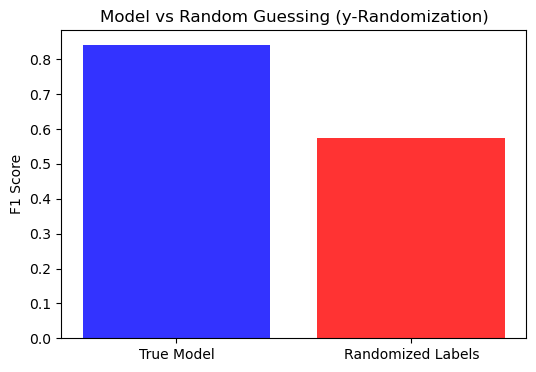

In [55]:
#Evaluate performance on true labels (CV results already known)
true_f1 = grid_search_1.best_score_
true_acc = grid_search_1.cv_results_['mean_test_accuracy'][grid_search_1.best_index_]

print(f"LASSO performance (CV): Accuracy = {true_acc:.4f}, F1 = {true_f1:.4f}")

# y-Randomization (shuffle labels, retrain same model)
rand_accs, rand_f1s = [], []

for i in range(20):
    y_shuffled = shuffle(train_Y_idless.values.ravel(), random_state=i)
    log_reg_rand = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=grid_search_1.best_params_['C'],
        max_iter=10000
    )
    log_reg_rand.fit(X_trainS, y_shuffled)
    y_pred_rand = log_reg_rand.predict(X_trainS)
    rand_accs.append(accuracy_score(train_Y_idless, y_pred_rand))
    rand_f1s.append(f1_score(train_Y_idless, y_pred_rand))

# Average randomized performance
rand_acc_mean = np.mean(rand_accs)
rand_f1_mean = np.mean(rand_f1s)

print(f" Randomized-label performance (mean of {20} runs): "
      f"Accuracy = {rand_acc_mean:.4f}, F1 = {rand_f1_mean:.4f}")

#Visualization
plt.figure(figsize=(6,4))
plt.bar(['True Model', 'Randomized Labels'],
        [true_f1, rand_f1_mean],
        color=['blue', 'red'], alpha=0.8)
plt.ylabel("F1 Score")
plt.title("Model vs Random Guessing (y-Randomization)")
plt.show()



Top 10 most important genes:
ENSG00000177947    0.467814
ENSG00000174358    0.457185
ENSG00000130595    0.422744
ENSG00000180316    0.417026
ENSG00000153714    0.402332
ENSG00000221813    0.378900
ENSG00000136535    0.371879
ENSG00000204928    0.362428
ENSG00000168148    0.343737
ENSG00000244588    0.332979
dtype: float64


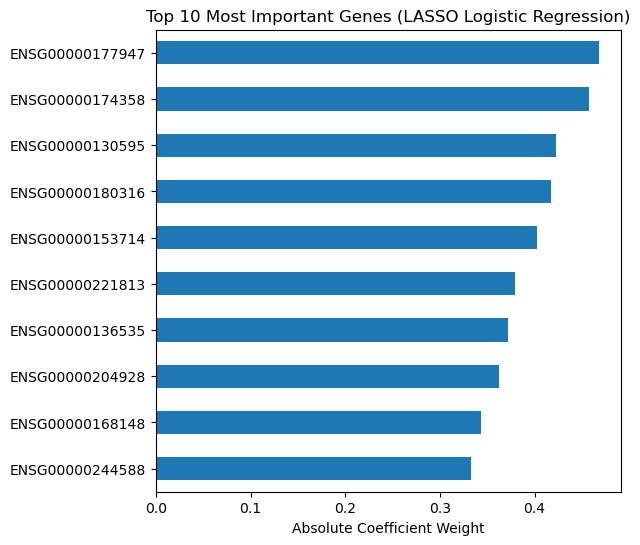

In [59]:
# Refit on entire training set using best C
best_model = grid_search_1.best_estimator_

y_pred_test = best_model.predict(X_testS)
submission = pd.DataFrame({'ID': test_X['Unnamed: 0'],'xml_neoplasm_histologic_grade': y_pred_test})
submission.to_csv("submission.csv", index=False)
# Feature importance (top genes)
coefs = pd.Series(best_model.coef_.ravel(), index=train_X_idless.columns)
top_genes = coefs.abs().sort_values(ascending=False).head(10)
print("\nTop 10 most important genes:")
print(top_genes)

# Plot top genes
plt.figure(figsize=(6, 6))
top_genes.sort_values().plot(kind='barh')
plt.title("Top 10 Most Important Genes (LASSO Logistic Regression)")
plt.xlabel("Absolute Coefficient Weight")
plt.show()


# Visualization of 2 groups

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_trainS)
umap_df = pd.DataFrame({
    'UMAP 1': X_umap[:, 0],
    'UMAP 2': X_umap[:, 1],
    'Class': train_Y_idless.values.ravel()
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='UMAP 1', 
    y='UMAP 2', 
    hue='Class', 
    data=umap_df,
    palette='twilight',
    s=70, 
)
plt.title('2D UMAP Visualization of Scaled Dataset')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend(title='Patient Group', loc='best')
plt.tight_layout()
plt.show()



## Write up:
The objective of this assignment was to build a classifier that accurately identifies if certain people present traits that indicate as carriers of uterine corpus endometrial carcinoma. I used a binary classifie then compared it with a lasso regression, a ridge regression, A simple line, and a Gaussian Naive Bayes Classifier. The model that performed the best is the Lasso regression.

My base model was just a standard binary classifier (logistic regression). When I added the penalty terms to the model to get the Lasso and Ridge regression, the model's F1 score improved greatly. The purpose of the penalty terms was to handle the noise in the data. By adding the penalties, the model performs better when comparing the Accuracy and F1 scores, especially for L1 (Lasso). 

I then compared these regression models with a "linear classifier" (using a line to classify the data) and a Gaussian Naive Bayes classifer. The F1 and Accuracy of the Lasso still out perfromed the Naive Bayes Classifier. However with the line, i suspect there may be some over fitting as the F1 value is 1.0. 

I then compared my scores of my best model to Random Guessing via y-randomization. With random guessing, the F1 and Accuracy scores are significantly lower, sitting around 0.5-0.58. HOwever, my best model results of around 0.84. So my model does outperform just random guessing.

I then tried to identify which Genes are possibly the most import when identifying if a person is a carrier. The most important based on my model is identified as ENSG00000177947. When i tried to compare my outputs to what genes are possibly relevant to the cancer, there is no match up. 

I then used a UMAP to visualize the 2 groups. There is some distinction between the 2 groups but not a whole lot. In my opinion this makes sense as the underlying genetic makeuo is similar.